In [2]:
import pandas as pd


In [3]:
u_df = pd.read_csv("../Dataset/archive (3)/mental_heath_unbanlanced.csv")
f_df = pd.read_csv("../Dataset/archive (3)/mental_heath_feature_engineered.csv")
t_df = pd.read_csv("../Dataset/archive (3)/mental_health_combined_test.csv")

In [4]:
print("UNBALANCED DATASET")
print(u_df.shape)
print(u_df.columns)

UNBALANCED DATASET
(49612, 3)
Index(['Unique_ID', 'text', 'status'], dtype='str')


In [5]:
print("FEATURE ENGINEERED DATASET")
print(f_df.shape)
print(f_df.columns)

FEATURE ENGINEERED DATASET
(49612, 21)
Index(['Unique_ID', 'text', 'status', 'text_length', 'word_count', 'num_urls',
       'num_emojis', 'num_special_chars', 'num_excess_punct',
       'avg_word_length', 'stopword_ratio', 'type_token_ratio', 'polarity',
       'subjectivity', 'noun_ratio', 'verb_ratio', 'adj_ratio', 'adv_ratio',
       'has_suicidal_keyword', 'has_stress_keyword', 'has_help_keyword'],
      dtype='str')


In [6]:
print("TEST DATASET")
print(t_df.shape)
print(t_df.columns)

TEST DATASET
(992, 2)
Index(['text', 'status'], dtype='str')


In [7]:
display(u_df.head)

<bound method NDFrame.head of        Unique_ID                                               text  \
0            0.0                                         oh my gosh   
1            1.0  trouble sleeping, confused mind, restless hear...   
2            2.0  All wrong, back off dear, forward doubt. Stay ...   
3            3.0  I've shifted my focus to something else but I'...   
4            4.0  I'm restless and restless, it's been a month n...   
...          ...                                                ...   
49607        NaN  i can't explain it but i know that i don't wan...   
49608        NaN  nobody ever told me that when i started treatm...   
49609        NaN  my wife and i split up in 2012/2013. she had a...   
49610        NaN  A close family member committed suicideI just ...   
49611        NaN  i am a high school english teacher. i am also ...   

           status  
0         Anxiety  
1         Anxiety  
2         Anxiety  
3         Anxiety  
4         Anxiety

In [8]:
display(f_df.head)

<bound method NDFrame.head of        Unique_ID                                               text  \
0            0.0                                         oh my gosh   
1            1.0  trouble sleeping, confused mind, restless hear...   
2            2.0  All wrong, back off dear, forward doubt. Stay ...   
3            3.0  I've shifted my focus to something else but I'...   
4            4.0  I'm restless and restless, it's been a month n...   
...          ...                                                ...   
49607        NaN  i can't explain it but i know that i don't wan...   
49608        NaN  nobody ever told me that when i started treatm...   
49609        NaN  my wife and i split up in 2012/2013. she had a...   
49610        NaN  A close family member committed suicideI just ...   
49611        NaN  i am a high school english teacher. i am also ...   

           status  text_length  word_count  num_urls  num_emojis  \
0         Anxiety     0.001678    0.007576       

In [9]:
#as feature data set contains all the relevant columns and rows
print("Shape:", f_df.shape)

Shape: (49612, 21)


In [10]:
print(f_df.columns.tolist())

['Unique_ID', 'text', 'status', 'text_length', 'word_count', 'num_urls', 'num_emojis', 'num_special_chars', 'num_excess_punct', 'avg_word_length', 'stopword_ratio', 'type_token_ratio', 'polarity', 'subjectivity', 'noun_ratio', 'verb_ratio', 'adj_ratio', 'adv_ratio', 'has_suicidal_keyword', 'has_stress_keyword', 'has_help_keyword']


In [11]:
f_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49612 entries, 0 to 49611
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unique_ID             40012 non-null  float64
 1   text                  49612 non-null  str    
 2   status                49612 non-null  str    
 3   text_length           40012 non-null  float64
 4   word_count            40012 non-null  float64
 5   num_urls              40012 non-null  float64
 6   num_emojis            40012 non-null  float64
 7   num_special_chars     40012 non-null  float64
 8   num_excess_punct      40012 non-null  float64
 9   avg_word_length       40012 non-null  float64
 10  stopword_ratio        40012 non-null  float64
 11  type_token_ratio      40012 non-null  float64
 12  polarity              40012 non-null  float64
 13  subjectivity          40012 non-null  float64
 14  noun_ratio            40012 non-null  float64
 15  verb_ratio            40012 no

In [12]:
f_df.isnull().sum()

Unique_ID               9600
text                       0
status                     0
text_length             9600
word_count              9600
num_urls                9600
num_emojis              9600
num_special_chars       9600
num_excess_punct        9600
avg_word_length         9600
stopword_ratio          9600
type_token_ratio        9600
polarity                9600
subjectivity            9600
noun_ratio              9600
verb_ratio              9600
adj_ratio               9600
adv_ratio               9600
has_suicidal_keyword    9600
has_stress_keyword      9600
has_help_keyword        9600
dtype: int64

In [13]:
print("Duplicate rows:", f_df.duplicated().sum())

Duplicate rows: 0


In [14]:
print("Duplicate texts:", f_df["text"].duplicated().sum())

Duplicate texts: 667


In [15]:
print(f_df["status"].unique())

<StringArray>
['Anxiety', 'Normal', 'Depression', 'Suicidal']
Length: 4, dtype: str


In [16]:
print(f_df["status"].value_counts())

status
Normal        18391
Depression    14506
Suicidal      11212
Anxiety        5503
Name: count, dtype: int64


In [17]:
print(f_df["status"].value_counts(normalize=True) * 100)

status
Normal        37.069661
Depression    29.238894
Suicidal      22.599371
Anxiety       11.092074
Name: proportion, dtype: float64


In [18]:
for i, text in enumerate(f_df["text"].sample(5, random_state=42)):
    print(f"\n--- Example {i+1} ---")
    print(text)


--- Example 1 ---
@slydevil damn right!, kinda hate myself for not having the system to lay it on... being poor sucks

--- Example 2 ---
How do you manage anxiety when sleep deprived? I am eating some good I haven't eaten for hours. I had a headache ive gotten like 2 hours sleep the past couple of nights. I walked out in the cold for a minute and turned the lights on. I had a bad dream that made me feel like I was going crazy.

--- Example 3 ---
3alam had 48

--- Example 4 ---
my bf said i dont try to make it better for myself like i dont hear it enough in my fucking head. i spent so many fucking years beating myself up and hearing it from my parents that i dont fucking try. i used to be fucking paralysed for years, at uni it built up so much that i fucked up my degree. i couldnt face looking after myself, ive tried meds even, nothing fucking works. i cant find any motivation to be a better person in the long run. something is so inherently wrong with me and i cant get help bc the hea

In [19]:
missing_feature_rows = f_df["polarity"].isnull()
print("rows with missing polarity:", missing_feature_rows.sum())

rows with missing polarity: 9600


In [20]:
engineered_features = [
    "text_length",
    "word_count",
    "num_urls",
    "num_emojis",
    "num_special_chars",
    "num_excess_punct",
    "avg_word_length",
    "stopword_ratio",
    "type_token_ratio",
    "polarity",
    "subjectivity",
    "noun_ratio",
    "verb_ratio",
    "adj_ratio",
    "adv_ratio" 
]

In [21]:
f_df[engineered_features].isnull().all(axis=1).sum()

np.int64(9600)

In [22]:
missing_indices = f_df.index[f_df["polarity"].isnull()]

print("First 20 missing-feature row indices:")
print(missing_indices[:20])

print("\nLast 20 missing-feature row indices:")
print(missing_indices[-20:])

First 20 missing-feature row indices:
RangeIndex(start=40012, stop=40032, step=1)

Last 20 missing-feature row indices:
RangeIndex(start=49592, stop=49612, step=1)


In [23]:
hybrid_df = f_df.iloc[:40012].copy()

In [24]:
hybrid_df.shape

(40012, 21)

In [25]:
print("Total missing values:", hybrid_df.isnull().sum().sum())

Total missing values: 0


In [26]:
print("Duplicate texts:", hybrid_df["text"].duplicated().sum())

Duplicate texts: 666


In [27]:
duplicate_texts = f_df[f_df["text"].duplicated(keep=False)]

print("Total rows involved in duplicate texts:",
      len(duplicate_texts))

print("Unique duplicated text values:",
      duplicate_texts["text"].nunique())

Total rows involved in duplicate texts: 1187
Unique duplicated text values: 520


In [28]:
duplicate_label_check = (
    duplicate_texts.groupby("text")["status"].nunique()
)

conflicting_duplicates = duplicate_label_check[duplicate_label_check > 1]

print("Number of duplicated texts with conflicting labels:", len(conflicting_duplicates))

Number of duplicated texts with conflicting labels: 10


In [29]:
if len(conflicting_duplicates) > 0:
    for text in conflicting_duplicates.index[:10]:
        print("text:", text)
        print(duplicate_texts[duplicate_texts["text"]==text][["text","status"]].to_string(index=False))
        print("-"*80)
            

text: All this work, all this pressure that everyone puts on you to succeed. To go to a good college, get a good job, the normal things a lot of parents ask. All for what? I work my entire life and then what? Am I supposed to enjoy my ofttimes from studying or working being an ugly, socially awkward loser? Not able to talk to anyone, have friends; even when doing normally enjoyed things (video games, time off, etc.) all I can think about is how everyone else is probably enjoying their time with other people. Am I working for something or am I just working for the sake of working just because everyone tells me that is what I am supposed to do. Do people only tell you it gets better for the sake of having one more wage slave satisfy their demand for goods? What is this all for? All for what?
                                                                                                                                                                                                       

In [30]:
hybrid_duplicate_label_check = (
    hybrid_df
    .groupby("text")["status"]
    .nunique()
)

hybrid_conflicting_duplicates = hybrid_duplicate_label_check[
    hybrid_duplicate_label_check > 1
]

print(
    "Conflicting duplicated texts in hybrid_df:",
    len(hybrid_conflicting_duplicates)
)

Conflicting duplicated texts in hybrid_df: 9


In [31]:
conflicting_rows = hybrid_df[
    hybrid_df["text"].isin(hybrid_conflicting_duplicates.index)
][["text", "status"]]

display(conflicting_rows)

,text,status
7637,"All this work, all this pressure that everyone...",Suicidal
7638,"All this work, all this pressure that everyone...",Depression
10984,I have been at home the past year... quite lit...,Suicidal
10989,I have been at home the past year... quite lit...,Depression
19080,My twin betrayed me and it cost me some of my ...,Suicidal
19082,My twin betrayed me and it cost me some of my ...,Depression
21002,we are able to fly space ships and control sat...,Suicidal
21005,we are able to fly space ships and control sat...,Depression
38203,need help with SSRI nausea I was wondering if ...,Depression
38296,Are my anti-depressants not working? I’ve (22F...,Depression


In [32]:
#data cleaning step
clean_hybrid_df = hybrid_df[
    ~hybrid_df["text"].isin(hybrid_conflicting_duplicates.index)
].copy()

In [33]:
clean_hybrid_df = hybrid_df[
    ~hybrid_df["text"].isin(hybrid_conflicting_duplicates.index)
].copy()

print("Original hybrid dataset:", hybrid_df.shape)
print("Clean hybrid dataset:", clean_hybrid_df.shape)

Original hybrid dataset: (40012, 21)
Clean hybrid dataset: (39990, 21)


In [34]:
numerical_features = [
    "text_length",
    "word_count",
    "num_urls",
    "num_emojis",
    "num_special_chars",
    "num_excess_punct",
    "avg_word_length",
    "stopword_ratio",
    "type_token_ratio",
    "polarity",
    "subjectivity",
    "noun_ratio",
    "verb_ratio",
    "adj_ratio",
    "adv_ratio"
]

clean_hybrid_df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
text_length,39990.0,0.255416,0.261547,0.0,0.041946,0.147651,0.408557,1.0
word_count,39990.0,0.231216,0.236202,0.0,0.037879,0.132576,0.367424,1.0
num_urls,39990.0,0.001960,0.020501,0.0,0.000000,0.000000,0.000000,0.8
num_emojis,39990.0,0.001373,0.017634,0.0,0.000000,0.000000,0.000000,1.0
num_special_chars,39990.0,0.002016,0.012873,0.0,0.000000,0.000000,0.000000,1.0
num_excess_punct,39990.0,0.003248,0.017016,0.0,0.000000,0.000000,0.000000,1.0
avg_word_length,39990.0,0.010816,0.006538,0.0,0.009202,0.010185,0.011517,1.0
stopword_ratio,39990.0,0.195627,0.096312,0.0,0.152226,0.203390,0.250000,1.0
type_token_ratio,39990.0,0.815645,0.157229,0.0,0.679082,0.822770,1.000000,1.0
polarity,39990.0,0.504061,0.128849,0.0,0.450000,0.500000,0.557143,1.0


In [35]:
keyword_features = [
    "has_suicidal_keyword",
    "has_stress_keyword",
    "has_help_keyword"
]

for feature in keyword_features:
    print(f"\n--- {feature} ---")
    print(clean_hybrid_df[feature].value_counts(dropna=False))


--- has_suicidal_keyword ---
has_suicidal_keyword
False    34303
1         5225
True       462
Name: count, dtype: int64

--- has_stress_keyword ---
has_stress_keyword
False    38693
1         1297
Name: count, dtype: int64

--- has_help_keyword ---
has_help_keyword
False    34512
1         5443
True        35
Name: count, dtype: int64


In [36]:
print(clean_hybrid_df["status"].value_counts())

status
Normal        15991
Depression    12095
Suicidal       8808
Anxiety        3096
Name: count, dtype: int64


In [37]:
print(clean_hybrid_df["status"].value_counts(normalize=True) * 100)

status
Normal        39.987497
Depression    30.245061
Suicidal      22.025506
Anxiety        7.741935
Name: proportion, dtype: float64


In [38]:
print("Total missing values:",
      clean_hybrid_df.isnull().sum().sum())

Total missing values: 0


In [39]:
print(clean_hybrid_df[numerical_features].head())

   text_length  word_count  num_urls  num_emojis  num_special_chars  \
0     0.001678    0.007576       0.0         0.0                0.0   
1     0.046980    0.034091       0.0         0.0                0.0   
2     0.058725    0.049242       0.0         0.0                0.0   
3     0.044463    0.037879       0.0         0.0                0.0   
4     0.053691    0.049242       0.0         0.0                0.0   

   num_excess_punct  avg_word_length  stopword_ratio  type_token_ratio  \
0               0.0         0.005395        0.000000          1.000000   
1               0.0         0.015152        0.100000          1.000000   
2               0.0         0.012200        0.214286          0.926576   
3               0.0         0.012178        0.090909          1.000000   
4               0.0         0.010724        0.142857          1.000000   

   polarity  subjectivity  noun_ratio  verb_ratio  adj_ratio  adv_ratio  
0   0.50000        0.0000         0.0    0.000000   0.

In [40]:
print(clean_hybrid_df[[
    "text_length",
    "word_count",
    "avg_word_length",
    "polarity",
    "subjectivity"
]].corr())

                 text_length  word_count  avg_word_length  polarity  \
text_length         1.000000    0.995775        -0.069268 -0.044615   
word_count          0.995775    1.000000        -0.098847 -0.049571   
avg_word_length    -0.069268   -0.098847         1.000000  0.030860   
polarity           -0.044615   -0.049571         0.030860  1.000000   
subjectivity        0.243449    0.246133        -0.081840 -0.081393   

                 subjectivity  
text_length          0.243449  
word_count           0.246133  
avg_word_length     -0.081840  
polarity            -0.081393  
subjectivity         1.000000  


pd.crosstab():

pd.crosstab() creates a cross-tabulation between two variables.

Code:

pd.crosstab(
    clean_hybrid_df[feature],
    clean_hybrid_df["status"]
)

Means:

For each keyword feature value (0 or 1), show how the rows are distributed across Normal, Depression, Anxiety, and Suicidal.

In [41]:
for feature in keyword_features:
    print(f"\n---{feature} vs status---")
    
    print(pd.crosstab(clean_hybrid_df[feature],
                      clean_hybrid_df["status"],
                      normalize = "index")
          *100)


---has_suicidal_keyword vs status---
status                 Anxiety  Depression     Normal   Suicidal
has_suicidal_keyword                                            
1                     2.277512   34.373206   1.837321  61.511962
False                 8.658135   29.536775  46.299158  15.505932
True                  1.515152   36.147186   2.813853  59.523810

---has_stress_keyword vs status---
status                Anxiety  Depression     Normal   Suicidal
has_stress_keyword                                             
1                   33.924441   49.190439   3.238242  13.646877
False                6.864291   29.610007  41.219342  22.306360

---has_help_keyword vs status---
status             Anxiety  Depression     Normal   Suicidal
has_help_keyword                                            
1                 7.642844   52.636414   9.204483  30.516259
False             7.765415   26.715345  44.877144  20.642096
True              0.000000   28.571429   5.714286  65.714286


In [42]:
print(clean_hybrid_df["has_suicidal_keyword"].value_counts(dropna=False))
print(clean_hybrid_df["has_suicidal_keyword"].dtype)

has_suicidal_keyword
False    34303
1         5225
True       462
Name: count, dtype: int64
str


In [43]:
for feature in keyword_features:
    print(f"\n--- {feature} ---")
    print(clean_hybrid_df[feature].value_counts(dropna=False))
    print("dtype:", clean_hybrid_df[feature].dtype)


--- has_suicidal_keyword ---
has_suicidal_keyword
False    34303
1         5225
True       462
Name: count, dtype: int64
dtype: str

--- has_stress_keyword ---
has_stress_keyword
False    38693
1         1297
Name: count, dtype: int64
dtype: str

--- has_help_keyword ---
has_help_keyword
False    34512
1         5443
True        35
Name: count, dtype: int64
dtype: str


In [44]:
keyword_features = [
    "has_suicidal_keyword",
    "has_stress_keyword",
    "has_help_keyword"
]

for feature in keyword_features:
    clean_hybrid_df[feature] = (
        clean_hybrid_df[feature]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            "false": 0,
            "true": 1,
            "1": 1,
            "0": 0
        })
        .astype(int)
    )

In [45]:
for feature in keyword_features:
    print(f"\n--- {feature} ---")
    print(clean_hybrid_df[feature].value_counts(dropna=False))
    print("dtype:", clean_hybrid_df[feature].dtype)


--- has_suicidal_keyword ---
has_suicidal_keyword
0    34303
1     5687
Name: count, dtype: int64
dtype: int64

--- has_stress_keyword ---
has_stress_keyword
0    38693
1     1297
Name: count, dtype: int64
dtype: int64

--- has_help_keyword ---
has_help_keyword
0    34512
1     5478
Name: count, dtype: int64
dtype: int64


In [46]:
sample_suicidal = clean_hybrid_df[
    clean_hybrid_df["has_suicidal_keyword"] == 1
][["text", "status", "has_suicidal_keyword"]].sample(
    10,
    random_state=42
)

display(sample_suicidal)

,text,status,has_suicidal_keyword
19094,I have started getting thoughts again and its ...,Suicidal,1
21140,24F and I have been stuck in this situation fo...,Suicidal,1
30045,what now so i am 17 everyone knows i want to k...,Suicidal,1
12968,I wish I would just catch a fatal disease or s...,Suicidal,1
18456,"Living is not fun, I do not have any good days...",Suicidal,1
16993,If I was just sitting down comfortably and a k...,Depression,1
33272,there is no real deep rooted reason i want to ...,Depression,1
12975,So basically I was fed up of being controlled ...,Suicidal,1
22737,Ill try my very hardest and want to kill mysel...,Suicidal,1
13085,"When you mention suicide people are like ""oh n...",Suicidal,1


In [47]:
sample_stress = clean_hybrid_df[
    clean_hybrid_df["has_stress_keyword"] == 1
][["text", "status", "has_stress_keyword"]].sample(
    10,
    random_state=42
)

display(sample_stress)

,text,status,has_stress_keyword
28052,"Terrified of PCOS For the past 7 months, the f...",Anxiety,1
16160,\-do not know how to socialize\-do not have al...,Depression,1
29128,Anybody feel their anxiety is subconscious? I ...,Anxiety,1
33867,we re here to help we are online therapy platf...,Depression,1
39281,Overworked college student There’s a lot of pe...,Anxiety,1
32676,i havent left my house in week i quit my job i...,Depression,1
20869,Everyone always let us me be around them becau...,Depression,1
28269,Lymphoma fear Hey guys. I've been having a swo...,Anxiety,1
32238,feel anxious when i dont follow my routine exa...,Depression,1
6775,I have a close friend who has suffered from pe...,Depression,1


In [48]:
sample_help = clean_hybrid_df[
    clean_hybrid_df["has_help_keyword"] == 1
][["text", "status", "has_help_keyword"]].sample(
    10,
    random_state=42
)

display(sample_help)

,text,status,has_help_keyword
20395,My partner had to take the razor blade off of ...,Suicidal,1
38581,"When you don't like yourself, don't like your ...",Depression,1
1046,"mutual? gas, if via help rt like pls",Normal,1
31868,in the last month i started with a new therapi...,Depression,1
13702,I know we usually talk about our problems here...,Depression,1
2116,At the age of 25 is very important :..1. Don't...,Normal,1
20494,I feel so guilty for sending this because I do...,Suicidal,1
7634,"I was abused by my parents as a child, and I c...",Suicidal,1
21787,I cannot feel anything since 2016 and it is ge...,Depression,1
31642,i ve struggled with mental health issue since ...,Depression,1


In [49]:
from sklearn.model_selection import train_test_split

#input data
X = clean_hybrid_df["text"]

#target data
y = clean_hybrid_df["status"]

#split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 31992
Testing samples: 7998


In [50]:
print("Training distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training distribution:
status
Normal        39.988122
Depression    30.245061
Suicidal      22.024256
Anxiety        7.742561
Name: proportion, dtype: float64

Testing distribution:
status
Normal        39.984996
Depression    30.245061
Suicidal      22.030508
Anxiety        7.739435
Name: proportion, dtype: float64


In [51]:
#TF - IDF conversion of text into numerical features
from sklearn.feature_extraction.text import TfidfVectorizer

#create the TF - IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=20000,
    #ngram_range ----> 1 indicates unigram means single words
    #2 ----> indicates two word combinations feel anxious, very depressed like these
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape", X_train_tfidf.shape)
print("Testing TF-IDF shape", X_test_tfidf.shape)



Training TF-IDF shape (31992, 20000)
Testing TF-IDF shape (7998, 20000)


In [52]:
#Actual training starts using logistic regression

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter = 1000, class_weight="balanced", random_state=42)

#training the model
logistic_model.fit(X_train_tfidf, y_train)

print("trained")


trained


In [53]:
y_pred = logistic_model.predict(X_test_tfidf)
print("prediction generated!")
print("number of predictions:", len(y_pred))

prediction generated!
number of predictions: 7998


In [54]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

     Anxiety       0.81      0.90      0.85       619
  Depression       0.79      0.69      0.74      2419
      Normal       0.93      0.95      0.94      3198
    Suicidal       0.69      0.76      0.72      1762

    accuracy                           0.83      7998
   macro avg       0.81      0.83      0.81      7998
weighted avg       0.83      0.83      0.83      7998



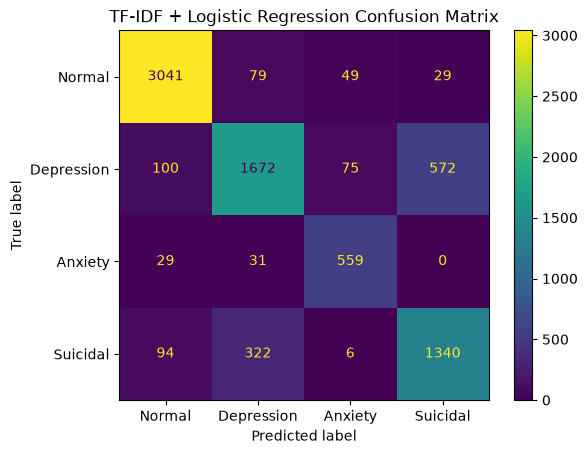

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Normal", "Depression", "Anxiety", "Suicidal"]
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Depression", "Anxiety", "Suicidal"]
)

disp.plot()
plt.title("TF-IDF + Logistic Regression Confusion Matrix")
plt.show()

In [56]:
# List of engineered features we want to use
feature_columns = [
    "text_length",
    "word_count",
    "num_urls",
    "num_emojis",
    "num_special_chars",
    "num_excess_punct",
    "avg_word_length",
    "stopword_ratio",
    "type_token_ratio",
    "polarity",
    "subjectivity",
    "noun_ratio",
    "verb_ratio",
    "adj_ratio",
    "adv_ratio",
    "has_suicidal_keyword",
    "has_stress_keyword",
    "has_help_keyword"
]

# Create the feature matrix
X_features = clean_hybrid_df[feature_columns]

# Create the target variable
y_features = clean_hybrid_df["status"]

# Check the shape
print("Feature matrix shape:", X_features.shape)
print("Target shape:", y_features.shape)

Feature matrix shape: (39990, 18)
Target shape: (39990,)


In [57]:
print(X_features.dtypes)

text_length             float64
word_count              float64
num_urls                float64
num_emojis              float64
num_special_chars       float64
num_excess_punct        float64
avg_word_length         float64
stopword_ratio          float64
type_token_ratio        float64
polarity                float64
subjectivity            float64
noun_ratio              float64
verb_ratio              float64
adj_ratio               float64
adv_ratio               float64
has_suicidal_keyword      int64
has_stress_keyword        int64
has_help_keyword          int64
dtype: object


In [58]:
from sklearn.model_selection import train_test_split

# Split engineered features into training and testing sets
X_features_train, X_features_test, y_features_train, y_features_test = train_test_split(
    X_features,
    y_features,
    test_size=0.20,
    random_state=42,
    stratify=y_features
)

# Check the shapes
print("Training features shape:", X_features_train.shape)
print("Testing features shape:", X_features_test.shape)

print("Training labels shape:", y_features_train.shape)
print("Testing labels shape:", y_features_test.shape)

Training features shape: (31992, 18)
Testing features shape: (7998, 18)
Training labels shape: (31992,)
Testing labels shape: (7998,)


In [59]:
#here comes geature scaling to normalize values or to maintain uniformity throughout the dataset
#we are using standard scalar
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Learn scaling parameters from training data
X_features_train_scaled = scaler.fit_transform(X_features_train)

# Apply the same scaling to test data
X_features_test_scaled = scaler.transform(X_features_test)

print("Scaled training shape:", X_features_train_scaled.shape)
print("Scaled testing shape:", X_features_test_scaled.shape)


Scaled training shape: (31992, 18)
Scaled testing shape: (7998, 18)


In [60]:
from sklearn.linear_model import LogisticRegression

# Create the feature-based Logistic Regression model
feature_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Train the model
feature_model.fit(
    X_features_train_scaled,
    y_features_train
)

print("Feature-based model training completed!")

Feature-based model training completed!


In [61]:
# Predict the classes for the test set
y_features_pred = feature_model.predict(
    X_features_test_scaled
)

print("Predictions generated!")
print("Number of predictions:", len(y_features_pred))

Predictions generated!
Number of predictions: 7998


In [62]:
from sklearn.metrics import classification_report

print(classification_report(
    y_features_test,
    y_features_pred
))

              precision    recall  f1-score   support

     Anxiety       0.29      0.55      0.38       619
  Depression       0.62      0.48      0.54      2419
      Normal       0.81      0.84      0.82      3198
    Suicidal       0.55      0.51      0.53      1762

    accuracy                           0.64      7998
   macro avg       0.57      0.60      0.57      7998
weighted avg       0.66      0.64      0.64      7998



In [63]:
print("Text training rows:", X_train.index[:10].tolist())
print("Feature training rows:", X_features_train.index[:10].tolist())

print("\nText testing rows:", X_test.index[:10].tolist())
print("Feature testing rows:", X_features_test.index[:10].tolist())

Text training rows: [11716, 33425, 22253, 30751, 39947, 15858, 25122, 5970, 34090, 12304]
Feature training rows: [11716, 33425, 22253, 30751, 39947, 15858, 25122, 5970, 34090, 12304]

Text testing rows: [35472, 32436, 27893, 6851, 39691, 20853, 3364, 32827, 27177, 15353]
Feature testing rows: [35472, 32436, 27893, 6851, 39691, 20853, 3364, 32827, 27177, 15353]


In [64]:
from scipy.sparse import hstack

# Combine TF-IDF features with engineered features
X_train_hybrid = hstack([
    X_train_tfidf,
    X_features_train_scaled
])

X_test_hybrid = hstack([
    X_test_tfidf,
    X_features_test_scaled
])

print("Hybrid training shape:", X_train_hybrid.shape)
print("Hybrid testing shape:", X_test_hybrid.shape)

Hybrid training shape: (31992, 20018)
Hybrid testing shape: (7998, 20018)


In [65]:
from sklearn.linear_model import LogisticRegression

hybrid_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

hybrid_model.fit(
    X_train_hybrid,
    y_train
)

print("Hybrid model training completed!")

Hybrid model training completed!


In [66]:
y_hybrid_pred = hybrid_model.predict(
    X_test_hybrid
)

print("Hybrid predictions generated!")

Hybrid predictions generated!


In [67]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_hybrid_pred
))

              precision    recall  f1-score   support

     Anxiety       0.80      0.90      0.85       619
  Depression       0.80      0.70      0.75      2419
      Normal       0.92      0.95      0.94      3198
    Suicidal       0.70      0.76      0.73      1762

    accuracy                           0.83      7998
   macro avg       0.81      0.83      0.81      7998
weighted avg       0.83      0.83      0.83      7998



In [68]:
#training with linear SVM model
from sklearn.svm import LinearSVC

hybrid_svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42,
    max_iter=5000
)

print("Hybrid SVM model created!")

Hybrid SVM model created!


In [69]:
hybrid_svm_model.fit(
    X_train_hybrid,
    y_train
)

print("Hybrid SVM training completed!")

Hybrid SVM training completed!


In [70]:
y_hybrid_svm_pred = hybrid_svm_model.predict(
    X_test_hybrid
)

print("Hybrid SVM predictions generated!")

Hybrid SVM predictions generated!


In [71]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_hybrid_svm_pred
))

              precision    recall  f1-score   support

     Anxiety       0.86      0.85      0.86       619
  Depression       0.77      0.70      0.74      2419
      Normal       0.93      0.96      0.94      3198
    Suicidal       0.69      0.72      0.70      1762

    accuracy                           0.82      7998
   macro avg       0.81      0.81      0.81      7998
weighted avg       0.82      0.82      0.82      7998



In [72]:
print(type(hybrid_model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [73]:
print("Coefficient shape:", hybrid_model.coef_.shape)
print("Classes:", hybrid_model.classes_)

Coefficient shape: (4, 20018)
Classes: ['Anxiety' 'Depression' 'Normal' 'Suicidal']


In [74]:
[name for name in dir() if "tfidf" in name.lower() or "vector" in name.lower()]

['TfidfVectorizer', 'X_test_tfidf', 'X_train_tfidf', 'tfidf']

In [75]:
#tfidf_feature_names = tfidf.get_feature_names_out()
print("Number of TF-IDF features:", len(tfidf_feature_names))
print("First 10 features:", tfidf_feature_names[:10])

NameError: name 'tfidf_feature_names' is not defined

In [ ]:
engineered_feature_names = [
    "text_length",
    "word_count",
    "num_urls",
    "num_emojis",
    "num_special_chars",
    "num_excess_punct",
    "avg_word_length",
    "stopword_ratio",
    "type_token_ratio",
    "polarity",
    "subjectivity",
    "noun_ratio",
    "verb_ratio",
    "adj_ratio",
    "adv_ratio",
    "has_suicidal_keyword",
    "has_stress_keyword",
    "has_help_keyword"
]

In [ ]:
all_feature_names = list(tfidf_feature_names) + engineered_feature_names

print("Total feature names:", len(all_feature_names))

Total feature names: 20018


In [ ]:
import pandas as pd

# Find the position of the Suicidal class
suicidal_index = list(hybrid_model.classes_).index("Suicidal")

# Get coefficients for Suicidal class
suicidal_coefficients = hybrid_model.coef_[suicidal_index]

# Create a DataFrame
suicidal_importance = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": suicidal_coefficients
})

# Sort from strongest positive to weakest
suicidal_importance = suicidal_importance.sort_values(
    by="coefficient",
    ascending=False
)

print(suicidal_importance.head(20))

        feature  coefficient
669          am     5.840944
15755  suicidal     5.640090
4659     do not     4.590417
3352     cannot     4.361318
15768   suicide     3.874934
11506    myself     3.267904
14240        rt     3.195231
9195         iâ     3.053822
13403     pills     2.946462
4646      do it     2.906135
9156        its     2.669242
8058   https co     2.587444
6949        gun     2.474845
1613    anymore     2.364703
6810    goodbye     2.363095
9813       life     2.291000
6366       fuck     2.275002
6389    fucking     2.270221
9537        kms     2.258258
13044  overdose     2.253180


In [ ]:
print(
    suicidal_importance.sort_values(
        by="coefficient",
        ascending=True
    ).head(20)
)

          feature  coefficient
4777          don    -6.936706
18412          ve    -4.231555
1520      anxiety    -3.537504
18515          wa    -2.758430
8255           im    -2.618006
4469         didn    -2.510874
10150          ll    -2.338141
4728        doesn    -2.165895
6970           ha    -2.144330
4804     don want    -2.107086
4697       do you    -2.056041
14154    restless    -1.967739
19592     worried    -1.934904
4790     don know    -1.921053
4336   depression    -1.851273
11679     nervous    -1.810220
610          also    -1.690726
8052         http    -1.686847
3700          com    -1.661047
19490         won    -1.658050


In [76]:
print(tfidf)

TfidfVectorizer(max_df=0.95, max_features=20000, min_df=2, ngram_range=(1, 2),
                sublinear_tf=True)


In [77]:
print([name for name in dir() if "train" in name.lower()])
print([name for name in dir() if "test" in name.lower()])
print([name for name in dir() if "hybrid" in name.lower()])
print([name for name in dir() if "tfidf" in name.lower()])

['X_features_train', 'X_features_train_scaled', 'X_train', 'X_train_hybrid', 'X_train_tfidf', 'train_test_split', 'y_features_train', 'y_train']
['X_features_test', 'X_features_test_scaled', 'X_test', 'X_test_hybrid', 'X_test_tfidf', 'train_test_split', 'y_features_test', 'y_test']
['X_test_hybrid', 'X_train_hybrid', 'clean_hybrid_df', 'hybrid_conflicting_duplicates', 'hybrid_df', 'hybrid_duplicate_label_check', 'hybrid_model', 'hybrid_svm_model', 'y_hybrid_pred', 'y_hybrid_svm_pred']
['TfidfVectorizer', 'X_test_tfidf', 'X_train_tfidf', 'tfidf']


In [78]:
# Select the first sample from our test dataset
sample_index = 0

# Get the actual label
actual_label = y_test.iloc[sample_index]

print("Actual label:", actual_label)

Actual label: Normal


In [80]:
# Convert the hybrid test matrix from COO format to CSR format
X_test_hybrid = X_test_hybrid.tocsr()

print(type(X_test_hybrid))
print(X_test_hybrid.shape)

# Get the hybrid feature vector for our selected test sample
sample_hybrid = X_test_hybrid[sample_index]

# Make the prediction
sample_prediction = hybrid_model.predict(
    sample_hybrid
)[0]

# Get prediction probabilities
sample_probabilities = hybrid_model.predict_proba(
    sample_hybrid
)[0]

print("Actual label:", actual_label)
print("Predicted label:", sample_prediction)

print("\nClass probabilities:")

for class_name, probability in zip(
    hybrid_model.classes_,
    sample_probabilities
):
    print(f"{class_name}: {probability:.4f}")

<class 'scipy.sparse._csr.csr_matrix'>
(7998, 20018)
Actual label: Normal
Predicted label: Normal

Class probabilities:
Anxiety: 0.0732
Depression: 0.0399
Normal: 0.7757
Suicidal: 0.1113


In [81]:
# Find the position of the predicted class
predicted_class_index = list(
    hybrid_model.classes_
).index(sample_prediction)

print("Predicted class:", sample_prediction)
print("Class index:", predicted_class_index)

Predicted class: Normal
Class index: 2


In [82]:
# Get coefficients for the predicted class
predicted_class_coefficients = hybrid_model.coef_[
    predicted_class_index
]

# Convert the sample's hybrid feature vector into a 1D array
sample_vector = sample_hybrid.toarray()[0]

# Calculate each feature's local contribution
feature_contributions = (
    sample_vector *
    predicted_class_coefficients
)

print("Number of features:", len(feature_contributions))

Number of features: 20018


In [86]:
engineered_feature_names = [
    "text_length",
    "word_count",
    "num_urls",
    "num_emojis",
    "num_special_chars",
    "num_excess_punct",
    "avg_word_length",
    "stopword_ratio",
    "type_token_ratio",
    "polarity",
    "subjectivity",
    "noun_ratio",
    "verb_ratio",
    "adj_ratio",
    "adv_ratio",
    "has_suicidal_keyword",
    "has_stress_keyword",
    "has_help_keyword"
]
# Get the 20,000 TF-IDF feature names
tfidf_feature_names = tfidf.get_feature_names_out()

# Combine TF-IDF feature names and engineered feature names
all_feature_names = list(tfidf_feature_names) + engineered_feature_names

# Check the total number of feature names
print("Total feature names:", len(all_feature_names))

# Check the total number of features in the hybrid matrix
print("Total hybrid features:", X_test_hybrid.shape[1])

# Create a DataFrame containing the local explanation
local_explanation = pd.DataFrame({
    "feature": all_feature_names,
    "feature_value": sample_vector,
    "coefficient": predicted_class_coefficients,
    "contribution": feature_contributions
})

# Keep only features that are actually present in this sample
active_features = local_explanation[
    local_explanation["feature_value"] != 0
]

# Sort by strongest positive contribution
positive_contributors = active_features[
    active_features["contribution"] > 0
].sort_values(
    by="contribution",
    ascending=False
)

# Sort by strongest negative contribution
negative_contributors = active_features[
    active_features["contribution"] < 0
].sort_values(
    by="contribution",
    ascending=True
)

print("Top features supporting the prediction:")
print(positive_contributors.head(15))

print("\nTop features opposing the prediction:")
print(negative_contributors.head(15))

Total feature names: 20018
Total hybrid features: 20018
Top features supporting the prediction:
                    feature  feature_value  coefficient  contribution
20001            word_count      -0.800861    -1.346134      1.078067
20008      type_token_ratio       1.169225     0.751413      0.878571
20009              polarity       2.693050     0.136336      0.367159
20015  has_suicidal_keyword      -0.405049    -0.508610      0.206012
8300                     in       0.158805     0.351661      0.055845
20011            noun_ratio      -0.266035    -0.126167      0.033565
20016    has_stress_keyword      -0.183395    -0.159917      0.029328
6771                   good       0.272301     0.057175      0.015569
20014             adv_ratio      -0.502343    -0.029220      0.014679
20005      num_excess_punct      -0.190374    -0.049898      0.009499
20002              num_urls      -0.096184    -0.076085      0.007318
20017      has_help_keyword      -0.400174    -0.014450      0.0

In [87]:
print(X_train_hybrid.shape)
print(X_test_hybrid.shape)

print("\nEngineered feature columns:")
print(X_features_train.columns.tolist())

print("\nFirst 5 TF-IDF features:")
print(tfidf_feature_names[:5])

print("\nLast 5 TF-IDF features:")
print(tfidf_feature_names[-5:])

(31992, 20018)
(7998, 20018)

Engineered feature columns:
['text_length', 'word_count', 'num_urls', 'num_emojis', 'num_special_chars', 'num_excess_punct', 'avg_word_length', 'stopword_ratio', 'type_token_ratio', 'polarity', 'subjectivity', 'noun_ratio', 'verb_ratio', 'adj_ratio', 'adv_ratio', 'has_suicidal_keyword', 'has_stress_keyword', 'has_help_keyword']

First 5 TF-IDF features:
['00' '000' '00b' '02' '07']

Last 5 TF-IDF features:
['zone' 'zoom' 'âœ' 'ðÿ' 'ðÿ ðÿ']


In [88]:
# Number of TF-IDF features
num_tfidf_features = len(tfidf_feature_names)

# Separate local explanation into:
# 1. TF-IDF features
# 2. Engineered NLP features

local_tfidf_explanation = local_explanation.iloc[
    :num_tfidf_features
]

local_engineered_explanation = local_explanation.iloc[
    num_tfidf_features:
]

# Keep only active TF-IDF features
active_tfidf = local_tfidf_explanation[
    local_tfidf_explanation["feature_value"] != 0
]

# Keep only active engineered features
active_engineered = local_engineered_explanation[
    local_engineered_explanation["feature_value"] != 0
]

print("Active TF-IDF features:")
print(active_tfidf.sort_values(
    by="contribution",
    ascending=False
).head(10))

print("\nEngineered features:")
print(active_engineered.sort_values(
    by="contribution",
    ascending=False
))

Active TF-IDF features:
          feature  feature_value  coefficient  contribution
8300           in       0.158805     0.351661      0.055845
6771         good       0.272301     0.057175      0.015569
6796   good night       0.656574    -0.060115     -0.039470
17461          to       0.114426    -0.705755     -0.080756
11775       night       0.338182    -0.288952     -0.097718
989           and       0.127118    -1.458964     -0.185460
11689       never       0.262056    -1.009550     -0.264559
3551         chat       0.507199    -0.847970     -0.430090

Engineered features:
                    feature  feature_value  coefficient  contribution
20001            word_count      -0.800861    -1.346134      1.078067
20008      type_token_ratio       1.169225     0.751413      0.878571
20009              polarity       2.693050     0.136336      0.367159
20015  has_suicidal_keyword      -0.405049    -0.508610      0.206012
20011            noun_ratio      -0.266035    -0.126167      0.0

In [89]:
top_text_supporting = active_tfidf[
    active_tfidf["contribution"] > 0
].sort_values(
    by="contribution",
    ascending=False
).head(10)

print(top_text_supporting)

     feature  feature_value  coefficient  contribution
8300      in       0.158805     0.351661      0.055845
6771    good       0.272301     0.057175      0.015569


In [90]:
top_text_opposing = active_tfidf[
    active_tfidf["contribution"] < 0
].sort_values(
    by="contribution",
    ascending=True
).head(10)

print(top_text_opposing)

          feature  feature_value  coefficient  contribution
3551         chat       0.507199    -0.847970     -0.430090
11689       never       0.262056    -1.009550     -0.264559
989           and       0.127118    -1.458964     -0.185460
11775       night       0.338182    -0.288952     -0.097718
17461          to       0.114426    -0.705755     -0.080756
6796   good night       0.656574    -0.060115     -0.039470


In [91]:
engineered_supporting = active_engineered[
    active_engineered["contribution"] > 0
].sort_values(
    by="contribution",
    ascending=False
)

engineered_opposing = active_engineered[
    active_engineered["contribution"] < 0
].sort_values(
    by="contribution",
    ascending=True
)

print("Engineered features supporting prediction:")
print(engineered_supporting)

print("\nEngineered features opposing prediction:")
print(engineered_opposing)

Engineered features supporting prediction:
                    feature  feature_value  coefficient  contribution
20001            word_count      -0.800861    -1.346134      1.078067
20008      type_token_ratio       1.169225     0.751413      0.878571
20009              polarity       2.693050     0.136336      0.367159
20015  has_suicidal_keyword      -0.405049    -0.508610      0.206012
20011            noun_ratio      -0.266035    -0.126167      0.033565
20016    has_stress_keyword      -0.183395    -0.159917      0.029328
20014             adv_ratio      -0.502343    -0.029220      0.014679
20005      num_excess_punct      -0.190374    -0.049898      0.009499
20002              num_urls      -0.096184    -0.076085      0.007318
20017      has_help_keyword      -0.400174    -0.014450      0.005782
20013             adj_ratio      -1.021778    -0.003343      0.003416

Engineered features opposing prediction:
                 feature  feature_value  coefficient  contribution
20000   

In [92]:
def generate_suggestions(
    predicted_class,
    confidence,
    suicidal_keyword=0,
    stress_keyword=0,
    help_keyword=0
):
    suggestions = []

    # Convert prediction to standard format
    predicted_class = str(predicted_class).strip().lower()

    # -----------------------------------
    # NORMAL
    # -----------------------------------
    if predicted_class == "normal":

        suggestions.append(
            "Your text does not show strong indicators of significant "
            "mental health distress according to the model."
        )

        suggestions.append(
            "Continue maintaining healthy routines, adequate sleep, "
            "physical activity, and supportive social connections."
        )

        suggestions.append(
            "If your feelings change or become difficult to manage, "
            "consider talking to someone you trust."
        )

    # -----------------------------------
    # ANXIETY
    # -----------------------------------
    elif predicted_class == "anxiety":

        suggestions.append(
            "Consider trying a simple grounding or slow-breathing "
            "exercise when you feel overwhelmed."
        )

        suggestions.append(
            "Maintaining a regular sleep schedule, physical activity, "
            "and healthy daily routine may support emotional wellbeing."
        )

        if stress_keyword == 1:
            suggestions.append(
                "Your text contains indicators associated with stress. "
                "Consider identifying the immediate sources of stress "
                "and breaking difficult tasks into smaller steps."
            )

        suggestions.append(
            "If anxiety is persistent or significantly affects your "
            "daily life, consider speaking with a qualified mental-health professional."
        )

    # -----------------------------------
    # DEPRESSION
    # -----------------------------------
    elif predicted_class == "depression":

        suggestions.append(
            "Consider talking with someone you trust about how you are feeling."
        )

        suggestions.append(
            "Maintaining a regular routine, sleep schedule, physical activity, "
            "and social connection may support your wellbeing."
        )

        suggestions.append(
            "Try focusing on small, manageable activities rather than "
            "trying to solve everything at once."
        )

        if help_keyword == 1:
            suggestions.append(
                "Your text contains indicators suggesting a desire for support. "
                "Consider reaching out to someone you trust or a qualified professional."
            )

        suggestions.append(
            "If these feelings persist or interfere with daily life, "
            "consider seeking support from a qualified mental-health professional."
        )

    # -----------------------------------
    # SUICIDAL
    # -----------------------------------
    elif predicted_class == "suicidal":

        suggestions.append(
            "Your text contains indicators that may suggest significant distress."
        )

        suggestions.append(
            "Consider reaching out to someone you trust and letting them know "
            "how you are feeling."
        )

        suggestions.append(
            "Consider contacting a qualified mental-health professional "
            "for appropriate support."
        )

        if suicidal_keyword == 1:
            suggestions.append(
                "Because the text contains suicide-related indicators, "
                "it is important to take these signals seriously."
            )

        suggestions.append(
            "If you feel that you may act on thoughts of harming yourself "
            "or are in immediate danger, seek emergency help in your area immediately."
        )

    # -----------------------------------
    # UNKNOWN CLASS
    # -----------------------------------
    else:

        suggestions.append(
            "The model could not determine a recognised category. "
            "Consider reviewing the input and seeking professional support "
            "if you are experiencing significant distress."
        )

    return suggestions

In [93]:
test_classes = [
    "Normal",
    "Anxiety",
    "Depression",
    "Suicidal"
]

for category in test_classes:

    print("\n" + "=" * 60)
    print("PREDICTION:", category)
    print("=" * 60)

    suggestions = generate_suggestions(
        predicted_class=category,
        confidence=0.80,
        suicidal_keyword=0,
        stress_keyword=1,
        help_keyword=1
    )

    for i, suggestion in enumerate(suggestions, start=1):
        print(f"{i}. {suggestion}")


PREDICTION: Normal
1. Your text does not show strong indicators of significant mental health distress according to the model.
2. Continue maintaining healthy routines, adequate sleep, physical activity, and supportive social connections.
3. If your feelings change or become difficult to manage, consider talking to someone you trust.

PREDICTION: Anxiety
1. Consider trying a simple grounding or slow-breathing exercise when you feel overwhelmed.
2. Maintaining a regular sleep schedule, physical activity, and healthy daily routine may support emotional wellbeing.
3. Your text contains indicators associated with stress. Consider identifying the immediate sources of stress and breaking difficult tasks into smaller steps.
4. If anxiety is persistent or significantly affects your daily life, consider speaking with a qualified mental-health professional.

PREDICTION: Depression
1. Consider talking with someone you trust about how you are feeling.
2. Maintaining a regular routine, sleep schedu

In [95]:
# Your existing prediction
predicted_class = sample_prediction

# Get class probabilities
sample_probabilities = hybrid_model.predict_proba(
    sample_vector.reshape(1, -1)
)[0]

# Get confidence of predicted class
predicted_class_index = list(
    hybrid_model.classes_
).index(predicted_class)

confidence = sample_probabilities[
    predicted_class_index
]

print("Predicted class:", predicted_class)
print("Confidence:", round(confidence * 100, 2), "%")

Predicted class: Normal
Confidence: 77.57 %


In [97]:
# Get the original, unscaled engineered features
# for the same sample we are explaining

sample_engineered_original = X_features_test.iloc[[sample_index]]

print("Original engineered feature values:")
print(sample_engineered_original.T)


suicidal_keyword_value = int(
    sample_engineered_original["has_suicidal_keyword"].iloc[0]
)

stress_keyword_value = int(
    sample_engineered_original["has_stress_keyword"].iloc[0]
)

help_keyword_value = int(
    sample_engineered_original["has_help_keyword"].iloc[0]
)

print("Suicidal keyword:", suicidal_keyword_value)
print("Stress keyword:", stress_keyword_value)
print("Help keyword:", help_keyword_value)

stress_keyword_value = int(
    sample_engineered_original["has_stress_keyword"].iloc[0]
)

help_keyword_value = int(
    sample_engineered_original["has_help_keyword"].iloc[0]
)

print("Suicidal keyword:", suicidal_keyword_value)
print("Stress keyword:", stress_keyword_value)
print("Help keyword:", help_keyword_value)

Original engineered feature values:
                         35472
text_length           0.051174
word_count            0.041667
num_urls              0.000000
num_emojis            0.000000
num_special_chars     0.000000
num_excess_punct      0.000000
avg_word_length       0.012856
stopword_ratio        0.250000
type_token_ratio      1.000000
polarity              0.850000
subjectivity          0.600000
noun_ratio            0.000000
verb_ratio            0.083333
adj_ratio             0.000000
adv_ratio             0.000000
has_suicidal_keyword  0.000000
has_stress_keyword    0.000000
has_help_keyword      0.000000
Suicidal keyword: 0
Stress keyword: 0
Help keyword: 0
Suicidal keyword: 0
Stress keyword: 0
Help keyword: 0


In [98]:
suggestions = generate_suggestions(
    predicted_class=predicted_class,
    confidence=confidence,
    suicidal_keyword=suicidal_keyword_value,
    stress_keyword=stress_keyword_value,
    help_keyword=help_keyword_value
)

print("\nSuggestions:")

for i, suggestion in enumerate(suggestions, start=1):
    print(f"{i}. {suggestion}")


Suggestions:
1. Your text does not show strong indicators of significant mental health distress according to the model.
2. Continue maintaining healthy routines, adequate sleep, physical activity, and supportive social connections.
3. If your feelings change or become difficult to manage, consider talking to someone you trust.


In [100]:
def explain_prediction(
    predicted_class,
    confidence,
    local_explanation,
    sample_engineered_original
):
    print("=" * 60)
    print("        MENTAL HEALTH DISTRESS ANALYSIS")
    print("=" * 60)

    # -----------------------------
    # Prediction
    # -----------------------------
    print(f"\nPrediction: {predicted_class}")
    print(f"Confidence: {confidence * 100:.2f}%")

    print("\nNote:")
    print(
        "This is an AI-based screening result and "
        "is not a clinical diagnosis."
    )

    # -----------------------------
    # Separate TF-IDF and NLP features
    # -----------------------------
    num_tfidf_features = len(tfidf_feature_names)

    tfidf_explanation = local_explanation.iloc[
        :num_tfidf_features
    ]

    engineered_explanation = local_explanation.iloc[
        num_tfidf_features:
    ]

    # -----------------------------
    # Active TF-IDF features
    # -----------------------------
    active_tfidf = tfidf_explanation[
        tfidf_explanation["feature_value"] != 0
    ]

    # Supporting words
    supporting_words = active_tfidf[
        active_tfidf["contribution"] > 0
    ].sort_values(
        by="contribution",
        ascending=False
    ).head(5)

    # Opposing words
    opposing_words = active_tfidf[
        active_tfidf["contribution"] < 0
    ].sort_values(
        by="contribution",
        ascending=True
    ).head(5)

    # -----------------------------
    # Engineered features
    # -----------------------------
    active_engineered = engineered_explanation[
        engineered_explanation["feature_value"] != 0
    ]

    supporting_engineered = active_engineered[
        active_engineered["contribution"] > 0
    ].sort_values(
        by="contribution",
        ascending=False
    ).head(5)

    opposing_engineered = active_engineered[
        active_engineered["contribution"] < 0
    ].sort_values(
        by="contribution",
        ascending=True
    ).head(5)

    # -----------------------------
    # Display XAI
    # -----------------------------
    print("\n" + "-" * 60)
    print("WHY DID THE MODEL MAKE THIS PREDICTION?")
    print("-" * 60)

    print("\nTextual factors supporting prediction:")

    if len(supporting_words) == 0:
        print("• No strong textual factors identified.")
    else:
        for feature in supporting_words["feature"]:
            print(f"• {feature}")

    print("\nTextual factors opposing prediction:")

    if len(opposing_words) == 0:
        print("• No strong opposing textual factors identified.")
    else:
        for feature in opposing_words["feature"]:
            print(f"• {feature}")

    print("\nEngineered NLP features supporting prediction:")

    if len(supporting_engineered) == 0:
        print("• No strong engineered features identified.")
    else:
        for feature in supporting_engineered["feature"]:
            print(f"• {feature}")

    print("\nEngineered NLP features opposing prediction:")

    if len(opposing_engineered) == 0:
        print("• No strong opposing engineered features identified.")
    else:
        for feature in opposing_engineered["feature"]:
            print(f"• {feature}")

    # -----------------------------
    # Keyword indicators
    # -----------------------------
    suicidal_keyword = int(
        sample_engineered_original[
            "has_suicidal_keyword"
        ].iloc[0]
    )

    stress_keyword = int(
        sample_engineered_original[
            "has_stress_keyword"
        ].iloc[0]
    )

    help_keyword = int(
        sample_engineered_original[
            "has_help_keyword"
        ].iloc[0]
    )

    print("\nKeyword indicators:")

    print(
        f"• Suicidal keyword detected: "
        f"{'Yes' if suicidal_keyword == 1 else 'No'}"
    )

    print(
        f"• Stress keyword detected: "
        f"{'Yes' if stress_keyword == 1 else 'No'}"
    )

    print(
        f"• Help keyword detected: "
        f"{'Yes' if help_keyword == 1 else 'No'}"
    )

    # -----------------------------
    # Suggestions
    # -----------------------------
    suggestions = generate_suggestions(
        predicted_class=predicted_class,
        confidence=confidence,
        suicidal_keyword=suicidal_keyword,
        stress_keyword=stress_keyword,
        help_keyword=help_keyword
    )

    print("\n" + "-" * 60)
    print("SUGGESTIONS")
    print("-" * 60)

    for i, suggestion in enumerate(
        suggestions,
        start=1
    ):
        print(f"{i}. {suggestion}")

    print("\n" + "=" * 60)
    
    
    explain_prediction(
    predicted_class=predicted_class,
    confidence=confidence,
    local_explanation=local_explanation,
    sample_engineered_original=sample_engineered_original
)

In [102]:
%whos

Variable                        Type                      Data/Info
-------------------------------------------------------------------
ConfusionMatrixDisplay          type                      <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
LinearSVC                       type                      <class 'sklearn.svm._classes.LinearSVC'>
LogisticRegression              type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
StandardScaler                  type                      <class 'sklearn.preproces<...>ng._data.StandardScaler'>
TfidfVectorizer                 type                      <class 'sklearn.feature_e<...>on.text.TfidfVectorizer'>
X                               Series                    Shape: (39990,)
X_features                      DataFrame                 Shape: (39990, 18)
X_features_test                 DataFrame                 Shape: (7998, 18)
X_features_test_scaled          ndarray                   7998x18: 143964 elems, t

In [103]:
print("MODELS / VECTORIZER / SCALER")
print("-" * 40)

for name in [
    "hybrid_model",
    "hybrid_svm_model",
    "tfidf",
    "tfidf_vectorizer",
    "scaler",
    "feature_scaler",
    "standard_scaler"
]:
    if name in globals():
        obj = globals()[name]
        print(name, "→", type(obj))

MODELS / VECTORIZER / SCALER
----------------------------------------
hybrid_model → <class 'sklearn.linear_model._logistic.LogisticRegression'>
hybrid_svm_model → <class 'sklearn.svm._classes.LinearSVC'>
tfidf → <class 'sklearn.feature_extraction.text.TfidfVectorizer'>
scaler → <class 'sklearn.preprocessing._data.StandardScaler'>


In [104]:
print("DATA SHAPES")
print("-" * 40)

print("X_train_tfidf:", X_train_tfidf.shape)
print("X_test_tfidf:", X_test_tfidf.shape)

print("X_train_hybrid:", X_train_hybrid.shape)
print("X_test_hybrid:", X_test_hybrid.shape)

print("X_features_train:", X_features_train.shape)
print("X_features_test:", X_features_test.shape)

print("Feature names:", len(all_feature_names))

DATA SHAPES
----------------------------------------
X_train_tfidf: (31992, 20000)
X_test_tfidf: (7998, 20000)
X_train_hybrid: (31992, 20018)
X_test_hybrid: (7998, 20018)
X_features_train: (31992, 18)
X_features_test: (7998, 18)
Feature names: 20018


In [111]:
new_text = """
I have been feeling very stressed and overwhelmed lately.
I cannot concentrate on my studies and I feel exhausted all the time.
"""

new_text_tfidf = tfidf.transform([new_text])

print("New TF-IDF shape:", new_text_tfidf.shape)


New TF-IDF shape: (1, 20000)


In [117]:
import re
import numpy as np
import pandas as pd
from textblob import TextBlob

def extract_features_from_text(text):
    
    text = str(text)
    
    # -----------------------------
    # Basic text statistics
    # -----------------------------
    
    words = text.split()
    
    text_length = len(text)
    word_count = len(words)
    
    if word_count > 0:
        avg_word_length = (
            sum(len(word) for word in words) / word_count
        )
    else:
        avg_word_length = 0
    
    # -----------------------------
    # URL count
    # -----------------------------
    
    num_urls = len(
        re.findall(
            r'https?://\S+|www\.\S+',
            text
        )
    )
    
    # -----------------------------
    # Emoji count
    # -----------------------------
    
    num_emojis = len(
        re.findall(
            r'[\U0001F300-\U0001FAFF]',
            text
        )
    )
    
    # -----------------------------
    # Special characters
    # -----------------------------
    
    num_special_chars = len(
        re.findall(
            r'[^a-zA-Z0-9\s]',
            text
        )
    )
    
    # -----------------------------
    # Excess punctuation
    # -----------------------------
    
    num_excess_punct = len(
        re.findall(
            r'[!?.,]{2,}',
            text
        )
    )
    
    # -----------------------------
    # Stopword ratio
    # -----------------------------
    
    stopwords = {
        'a', 'an', 'the', 'and', 'or', 'but',
        'if', 'is', 'are', 'was', 'were',
        'to', 'of', 'in', 'on', 'for',
        'with', 'as', 'at', 'by', 'from',
        'it', 'this', 'that', 'i', 'you',
        'he', 'she', 'we', 'they'
    }
    
    if word_count > 0:
        stopword_count = sum(
            1 for word in words
            if word.lower() in stopwords
        )
        
        stopword_ratio = stopword_count / word_count
    else:
        stopword_ratio = 0
    
    # -----------------------------
    # Type-token ratio
    # -----------------------------
    
    unique_words = set(
        word.lower()
        for word in words
    )
    
    if word_count > 0:
        type_token_ratio = (
            len(unique_words) / word_count
        )
    else:
        type_token_ratio = 0
    
    # -----------------------------
    # Sentiment
    # -----------------------------
    
    sentiment = TextBlob(text).sentiment
    
    polarity = sentiment.polarity
    subjectivity = sentiment.subjectivity
    
    # -----------------------------
    # POS ratios
    # -----------------------------
    
    tagged_words = TextBlob(text).tags
    
    if len(tagged_words) > 0:
        
        total_tags = len(tagged_words)
        
        noun_count = sum(
            1 for _, tag in tagged_words
            if tag.startswith("NN")
        )
        
        verb_count = sum(
            1 for _, tag in tagged_words
            if tag.startswith("VB")
        )
        
        adj_count = sum(
            1 for _, tag in tagged_words
            if tag.startswith("JJ")
        )
        
        adv_count = sum(
            1 for _, tag in tagged_words
            if tag.startswith("RB")
        )
        
        noun_ratio = noun_count / total_tags
        verb_ratio = verb_count / total_tags
        adj_ratio = adj_count / total_tags
        adv_ratio = adv_count / total_tags
        
    else:
        
        noun_ratio = 0
        verb_ratio = 0
        adj_ratio = 0
        adv_ratio = 0
    
    # -----------------------------
    # Keyword features
    # -----------------------------
    
    text_lower = text.lower()
    
    suicidal_keywords = [
        "suicide",
        "suicidal",
        "kill myself",
        "kill me",
        "want to die",
        "wanna die",
        "end my life",
        "end it all",
        "take my life",
        "overdose",
        "self harm",
        "self-harm"
    ]
    
    stress_keywords = [
        "stress",
        "stressed",
        "pressure",
        "overwhelmed",
        "burnout",
        "exhausted",
        "overworked"
    ]
    
    help_keywords = [
        "help me",
        "need help",
        "someone help",
        "need support",
        "looking for help",
        "therapy",
        "therapist",
        "counselling",
        "counseling"
    ]
    
    has_suicidal_keyword = int(
        any(
            keyword in text_lower
            for keyword in suicidal_keywords
        )
    )
    
    has_stress_keyword = int(
        any(
            keyword in text_lower
            for keyword in stress_keywords
        )
    )
    
    has_help_keyword = int(
        any(
            keyword in text_lower
            for keyword in help_keywords
        )
    )
    
    # -----------------------------
    # Create DataFrame
    # -----------------------------
    
    features = pd.DataFrame([{
        "text_length": text_length,
        "word_count": word_count,
        "num_urls": num_urls,
        "num_emojis": num_emojis,
        "num_special_chars": num_special_chars,
        "num_excess_punct": num_excess_punct,
        "avg_word_length": avg_word_length,
        "stopword_ratio": stopword_ratio,
        "type_token_ratio": type_token_ratio,
        "polarity": polarity,
        "subjectivity": subjectivity,
        "noun_ratio": noun_ratio,
        "verb_ratio": verb_ratio,
        "adj_ratio": adj_ratio,
        "adv_ratio": adv_ratio,
        "has_suicidal_keyword": has_suicidal_keyword,
        "has_stress_keyword": has_stress_keyword,
        "has_help_keyword": has_help_keyword
    }])
    
    return features
# Create engineered features for the new text
new_features = extract_features_from_text(new_text)

# Make sure the columns are in exactly the same order as training
new_features = new_features[
    X_features_train.columns
]

print("New engineered features shape:", new_features.shape)
print("\nNew engineered features:")
print(new_features.T)

# Scale engineered features using the SAME scaler fitted during training
new_features_scaled = scaler.transform(new_features)

print("Scaled feature shape:", new_features_scaled.shape)

New engineered features shape: (1, 18)

New engineered features:
                               0
text_length           129.000000
word_count             22.000000
num_urls                0.000000
num_emojis              0.000000
num_special_chars       2.000000
num_excess_punct        0.000000
avg_word_length         4.818182
stopword_ratio          0.318182
type_token_ratio        0.863636
polarity               -0.166667
subjectivity            0.533333
noun_ratio              0.086957
verb_ratio              0.304348
adj_ratio               0.043478
adv_ratio               0.130435
has_suicidal_keyword    0.000000
has_stress_keyword      1.000000
has_help_keyword        0.000000
Scaled feature shape: (1, 18)


In [118]:
new_features = extract_features_from_text(new_text)

new_features = new_features[
    X_features_train.columns
]

print("New engineered features shape:", new_features.shape)
print(new_features.T)

New engineered features shape: (1, 18)
                               0
text_length           129.000000
word_count             22.000000
num_urls                0.000000
num_emojis              0.000000
num_special_chars       2.000000
num_excess_punct        0.000000
avg_word_length         4.818182
stopword_ratio          0.318182
type_token_ratio        0.863636
polarity               -0.166667
subjectivity            0.533333
noun_ratio              0.086957
verb_ratio              0.304348
adj_ratio               0.043478
adv_ratio               0.130435
has_suicidal_keyword    0.000000
has_stress_keyword      1.000000
has_help_keyword        0.000000


In [119]:
new_features_scaled = scaler.transform(new_features)

print("Scaled feature shape:", new_features_scaled.shape)

Scaled feature shape: (1, 18)


In [120]:
new_text_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 29 stored elements and shape (1, 20000)>

In [121]:
new_hybrid = hstack([
    new_text_tfidf,
    new_features_scaled
]).tocsr()

print("New hybrid shape:", new_hybrid.shape)

New hybrid shape: (1, 20018)


In [122]:
new_prediction = hybrid_model.predict(new_hybrid)[0]

print("Predicted label:", new_prediction)

Predicted label: Anxiety


In [123]:
new_probabilities = hybrid_model.predict_proba(new_hybrid)[0]

print("\nClass probabilities:")

for class_name, probability in zip(
    hybrid_model.classes_,
    new_probabilities
):
    print(f"{class_name}: {probability:.4f}")


Class probabilities:
Anxiety: 1.0000
Depression: 0.0000
Normal: 0.0000
Suicidal: 0.0000


In [124]:
new_confidence = max(new_probabilities)

print(f"\nConfidence: {new_confidence * 100:.2f}%")


Confidence: 100.00%


In [125]:
import inspect

print(inspect.signature(explain_prediction))
print(inspect.signature(generate_suggestions))

(predicted_class, confidence, local_explanation, sample_engineered_original)
(predicted_class, confidence, suicidal_keyword=0, stress_keyword=0, help_keyword=0)


In [126]:
new_confidence = max(new_probabilities)

In [127]:
# Get coefficients for the predicted class
predicted_class_index = list(
    hybrid_model.classes_
).index(new_prediction)

predicted_class_coefficients = (
    hybrid_model.coef_[predicted_class_index]
)

# Convert hybrid vector to dense array
sample_vector = new_hybrid.toarray()[0]

# Calculate feature contributions
feature_contributions = (
    sample_vector *
    predicted_class_coefficients
)

# Create local explanation DataFrame
local_explanation = pd.DataFrame({
    "feature": all_feature_names,
    "feature_value": sample_vector,
    "coefficient": predicted_class_coefficients,
    "contribution": feature_contributions
})

# Sort by absolute contribution
local_explanation = local_explanation.loc[
    local_explanation["contribution"]
    .abs()
    .sort_values(ascending=False)
    .index
]

print(local_explanation.head(20))

                  feature  feature_value  coefficient  contribution
20000         text_length     491.780198     2.458800   1209.188953
20001          word_count      91.991716    -2.100266   -193.207069
20004   num_special_chars     154.328302     0.169226     26.116347
20006     avg_word_length     680.255113    -0.033289    -22.645276
20016  has_stress_keyword       5.452705     0.094678      0.516252
3352               cannot       0.108167    -3.492242     -0.377744
5785              feeling       0.124784     1.738309      0.216914
7268            have been       0.125040    -1.722637     -0.215399
9663               lately       0.183996     0.889346      0.163636
15629            stressed       0.214853     0.751061      0.161367
12611               on my       0.155709     1.035732      0.161273
3787       concentrate on       0.301633     0.496735      0.149832
16618            the time       0.158408     0.807579      0.127927
15631        stressed and       0.280776     0.3

In [128]:
sample_engineered_original = new_features.iloc[0]

In [130]:
suicidal_keyword = int(
    new_features["has_suicidal_keyword"].iloc[0]
)

stress_keyword = int(
    new_features["has_stress_keyword"].iloc[0]
)

help_keyword = int(
    new_features["has_help_keyword"].iloc[0]
)

In [131]:
suggestions = generate_suggestions(
    new_prediction,
    new_confidence,
    suicidal_keyword,
    stress_keyword,
    help_keyword
)

print(suggestions)

['Consider trying a simple grounding or slow-breathing exercise when you feel overwhelmed.', 'Maintaining a regular sleep schedule, physical activity, and healthy daily routine may support emotional wellbeing.', 'Your text contains indicators associated with stress. Consider identifying the immediate sources of stress and breaking difficult tasks into smaller steps.', 'If anxiety is persistent or significantly affects your daily life, consider speaking with a qualified mental-health professional.']


In [ ]:
#final template

def analyze_text(new_text):
    
    # ---------------------------------
    # 1. Extract engineered features
    # ---------------------------------
    new_features = extract_features_from_text(new_text)
    
    # Keep exact training feature order
    new_features = new_features[
        X_features_train.columns
    ]
    
    # ---------------------------------
    # 2. TF-IDF transformation
    # ---------------------------------
    new_text_tfidf = tfidf.transform([new_text])
    
    # ---------------------------------
    # 3. Scale engineered features
    # ---------------------------------
    new_features_scaled = scaler.transform(
        new_features
    )
    
    # ---------------------------------
    # 4. Create hybrid feature vector
    # ---------------------------------
    new_hybrid = hstack([
        new_text_tfidf,
        new_features_scaled
    ]).tocsr()
    
    # ---------------------------------
    # 5. Prediction
    # ---------------------------------
    predicted_class = hybrid_model.predict(
        new_hybrid
    )[0]
    
    # ---------------------------------
    # 6. Probability
    # ---------------------------------
    probabilities = hybrid_model.predict_proba(
        new_hybrid
    )[0]
    
    confidence = max(probabilities)
    
    # ---------------------------------
    # 7. Get predicted class coefficients
    # ---------------------------------
    predicted_class_index = list(
        hybrid_model.classes_
    ).index(predicted_class)
    
    predicted_class_coefficients = (
        hybrid_model.coef_[predicted_class_index]
    )
    
    # ---------------------------------
    # 8. Calculate feature contributions
    # ---------------------------------
    sample_vector = new_hybrid.toarray()[0]
    
    feature_contributions = (
        sample_vector *
        predicted_class_coefficients
    )
    
    # ---------------------------------
    # 9. Create feature explanation
    # ---------------------------------
    local_explanation = pd.DataFrame({
        "feature": all_feature_names,
        "feature_value": sample_vector,
        "coefficient": predicted_class_coefficients,
        "contribution": feature_contributions
    })
    
    # Sort by importance
    local_explanation = local_explanation.loc[
        local_explanation["contribution"]
        .abs()
        .sort_values(ascending=False)
        .index
    ]
    
    # ---------------------------------
    # 10. Original engineered features
    # ---------------------------------
    sample_engineered_original = new_features.iloc[0]
    
    # ---------------------------------
    # 11. Keyword values
    # ---------------------------------
    suicidal_keyword = int(
        new_features[
            "has_suicidal_keyword"
        ].iloc[0]
    )
    
    stress_keyword = int(
        new_features[
            "has_stress_keyword"
        ].iloc[0]
    )
    
    help_keyword = int(
        new_features[
            "has_help_keyword"
        ].iloc[0]
    )
    
    # ---------------------------------
    # 12. Generate suggestions
    # ---------------------------------
    suggestions = generate_suggestions(
        predicted_class,
        confidence,
        suicidal_keyword,
        stress_keyword,
        help_keyword
    )
    
    # ---------------------------------
    # 13. Return everything
    # ---------------------------------
    return {
        "prediction": predicted_class,
        "confidence": confidence,
        "probabilities": dict(
            zip(
                hybrid_model.classes_,
                probabilities
            )
        ),
        "local_explanation": local_explanation,
        "engineered_features": sample_engineered_original,
        "suggestions": suggestions
    }

In [135]:
result = analyze_text(
    """
    I have been feeling very stressed and overwhelmed lately.
    I cannot concentrate on my studies and I feel exhausted all the time.
    """
)

print("Prediction:", result["prediction"])
print(
    "Confidence:",
    f"{result['confidence'] * 100:.2f}%"
)

print("\nProbabilities:")

for label, probability in result["probabilities"].items():
    print(
        f"{label}: "
        f"{probability * 100:.2f}%"
    )

Prediction: Anxiety
Confidence: 100.00%

Probabilities:
Anxiety: 100.00%
Depression: 0.00%
Normal: 0.00%
Suicidal: 0.00%


In [136]:
print("\nTop features supporting the prediction:")

supporting_features = result[
    "local_explanation"
][
    result["local_explanation"]["contribution"] > 0
].head(10)

print(
    supporting_features[
        [
            "feature",
            "feature_value",
            "contribution"
        ]
    ]
)


Top features supporting the prediction:
                  feature  feature_value  contribution
20000         text_length     537.617891   1321.894654
20004   num_special_chars     154.328302     26.116347
20016  has_stress_keyword       5.452705      0.516252
5785              feeling       0.124784      0.216914
9663               lately       0.183996      0.163636
15629            stressed       0.214853      0.161367
12611               on my       0.155709      0.161273
3787       concentrate on       0.301633      0.149832
16618            the time       0.158408      0.127927
15631        stressed and       0.280776      0.109461


In [137]:
print("\nTop features opposing the prediction:")

opposing_features = result[
    "local_explanation"
][
    result["local_explanation"]["contribution"] < 0
].head(10)

print(
    opposing_features[
        [
            "feature",
            "feature_value",
            "contribution"
        ]
    ]
)


Top features opposing the prediction:
               feature  feature_value  contribution
20001       word_count      91.991716   -193.207069
20006  avg_word_length     680.255113    -22.645276
3352            cannot       0.108167     -0.377744
7268         have been       0.125040     -0.215399
466                all       0.091267     -0.091431
20011       noun_ratio       1.576974     -0.080840
12554               on       0.088305     -0.074899
15673          studies       0.262381     -0.071213
1125          and feel       0.166792     -0.066999
20009         polarity      -5.211140     -0.058669


In [ ]:
print("\nSuggestions:")

for suggestion in result["suggestions"]:
    print(suggestion)



Suggestions:
Consider trying a simple grounding or slow-breathing exercise when you feel overwhelmed.
Maintaining a regular sleep schedule, physical activity, and healthy daily routine may support emotional wellbeing.
Your text contains indicators associated with stress. Consider identifying the immediate sources of stress and breaking difficult tasks into smaller steps.
If anxiety is persistent or significantly affects your daily life, consider speaking with a qualified mental-health professional.
['Consider trying a simple grounding or slow-breathing exercise when you feel overwhelmed.', 'Maintaining a regular sleep schedule, physical activity, and healthy daily routine may support emotional wellbeing.', 'Your text contains indicators associated with stress. Consider identifying the immediate sources of stress and breaking difficult tasks into smaller steps.', 'If anxiety is persistent or significantly affects your daily life, consider speaking with a qualified mental-health profess

In [112]:
[name for name in globals() if callable(globals()[name]) and not name.startswith("_")]

['get_ipython',
 'exit',
 'quit',
 'open',
 'train_test_split',
 'TfidfVectorizer',
 'LogisticRegression',
 'classification_report',
 'confusion_matrix',
 'ConfusionMatrixDisplay',
 'StandardScaler',
 'hstack',
 'LinearSVC',
 'generate_suggestions',
 'explain_prediction']

In [107]:
[name for name in globals() if "scal" in name.lower()]

['StandardScaler',
 'scaler',
 'X_features_train_scaled',
 'X_features_test_scaled']

In [140]:
import joblib
import os

# Create Models folder in project directory
models_path = "../Models"

os.makedirs(models_path, exist_ok=True)

# Save TF-IDF vectorizer
joblib.dump(
    tfidf,
    os.path.join(models_path, "tfidf_vectorizer.pkl")
)

# Save scaler
joblib.dump(
    scaler,
    os.path.join(models_path, "scaler.pkl")
)

# Save hybrid model
joblib.dump(
    hybrid_model,
    os.path.join(models_path, "hybrid_model.pkl")
)

print("Models saved successfully!")

Models saved successfully!


In [142]:
result = analyze_text(
    """
    i want to kill myself
    """
)

print("Prediction:", result["prediction"])
print(
    "Confidence:",
    f"{result['confidence'] * 100:.2f}%"
)

print("\nProbabilities:")

for label, probability in result["probabilities"].items():
    print(
        f"{label}: "
        f"{probability * 100:.2f}%"
    )

Prediction: Anxiety
Confidence: 100.00%

Probabilities:
Anxiety: 100.00%
Depression: 0.00%
Normal: 0.00%
Suicidal: 0.00%


NameError: name 'new_features' is not defined

In [101]:
analyze_text(new_text)

NameError: name 'analyze_text' is not defined

In [ ]:
import sys
print(sys.executable)

c:\Users\Lenovo\OneDrive\Desktop\MentalHealthDistressDetection\.venv\Scripts\python.exe
